# Spring of Code - Artificial Intelligence

## Week 05: Machine Learning

### Day 05: Polynomial Regression Simple


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [3]:
df = pd.read_csv (r"D:\NAVTTC-AI-Course\datasets\Ice_cream selling data.csv")
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


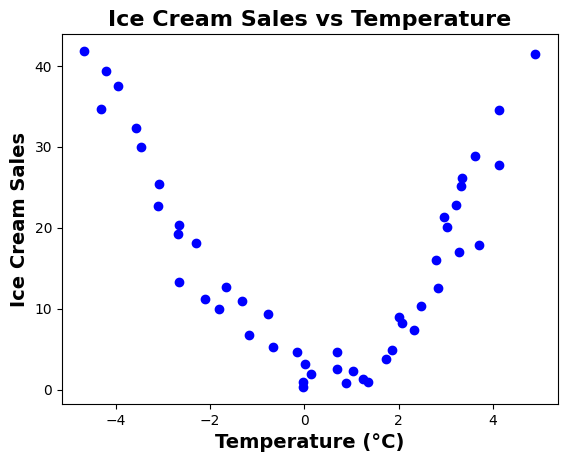

In [4]:
X = df['Temperature (°C)'].values.reshape(-1, 1)
y = df['Ice Cream Sales (units)'].values

plt.scatter(X, y, color='blue', label='Data Points')
plt.title('Ice Cream Sales vs Temperature', fontsize=16, fontweight='bold')
plt.xlabel('Temperature (°C)', fontsize=14, fontweight='bold')
plt.ylabel('Ice Cream Sales', fontsize=14, fontweight='bold')
plt.show()

Trained Model Successfully!


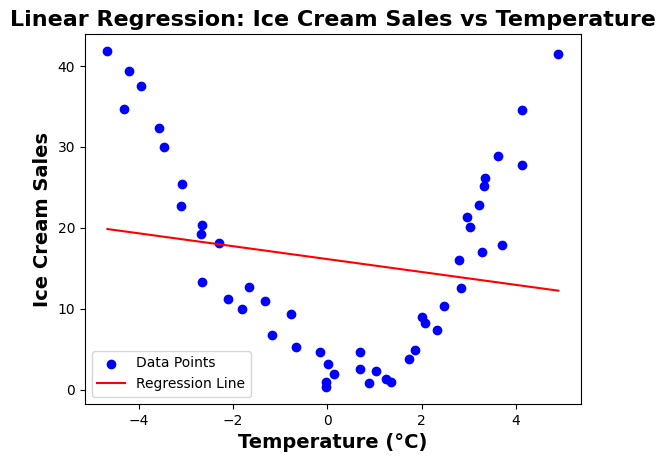

In [5]:
model = LinearRegression()
model.fit(X, y)
print('Trained Model Successfully!')

y_pred = model.predict(X)

# Plotting the data points and the regression line
plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X, y_pred, color='red', label='Regression Line')
plt.title('Linear Regression: Ice Cream Sales vs Temperature', fontsize=16, fontweight='bold')
plt.xlabel('Temperature (°C)', fontsize=14, fontweight='bold')
plt.ylabel('Ice Cream Sales', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

In [26]:
X.shape

(49, 1)

In [27]:
poly_features = PolynomialFeatures(degree=20)
X_poly = poly_features.fit_transform(X)
X_poly.shape

(49, 21)

Trained Polynomial Model Successfully!


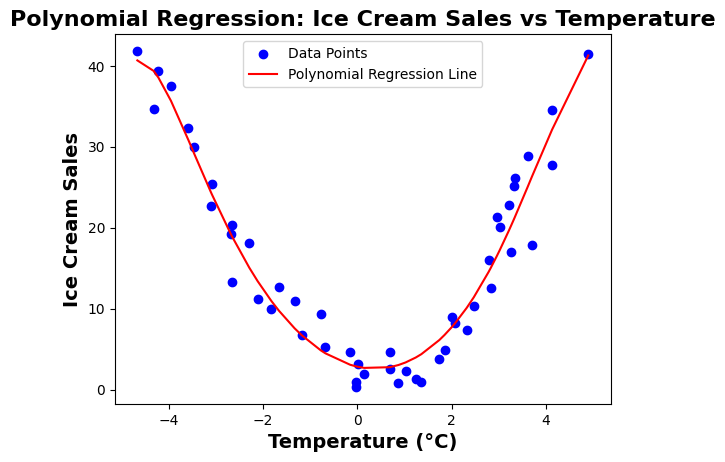

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
poly_features = PolynomialFeatures(degree=20)
X_poly = poly_features.fit_transform(X)
standard_scaler = StandardScaler()
X_poly_scale = standard_scaler.fit_transform(X_poly)

model = SGDRegressor(max_iter=10000, alpha = 0.001)
model.fit(X_poly_scale, y)
print('Trained Polynomial Model Successfully!')
y_poly_pred = model.predict(X_poly_scale)
plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X, y_poly_pred, color='red', label='Polynomial Regression Line')
plt.title('Polynomial Regression: Ice Cream Sales vs Temperature', fontsize=16, fontweight='bold')
plt.xlabel('Temperature (°C)', fontsize=14, fontweight='bold')
plt.ylabel('Ice Cream Sales', fontsize=14, fontweight='bold')
plt.legend()

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = False)

degree = 3

# Create the pipeline
poly_model = Pipeline([
    ("poly_features", PolynomialFeatures(degree=degree)),
    ('scaled_features', StandardScaler()),
    ("linear_regression", LinearRegression())
])

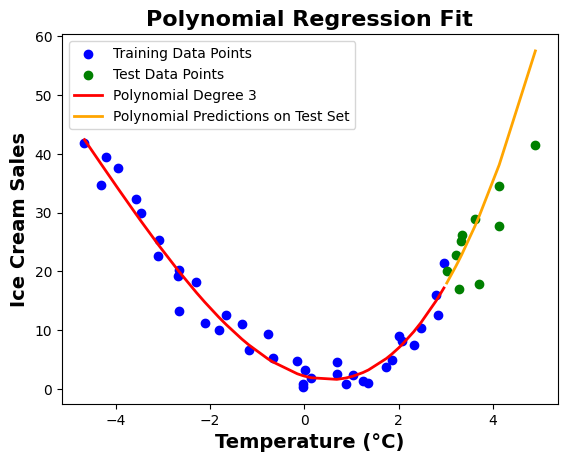

In [52]:
poly_model.fit(X_train, y_train)
y_pred = poly_model.predict(X_test)

# Plotting the original data points and the polynomial regression curve
plt.scatter(X_train, y_train, color='blue', label='Training Data Points')
plt.scatter(X_test, y_test, color='green', label='Test Data Points')
plt.plot(X_train, poly_model.predict(X_train), color='red', label=f'Polynomial Degree {degree}', linewidth=2)
plt.plot(X_test, y_pred, color='orange', label='Polynomial Predictions on Test Set', linewidth=2)
plt.title('Polynomial Regression Fit', fontsize=16, fontweight='bold')
plt.xlabel('Temperature (°C)', fontsize=14, fontweight='bold')
plt.ylabel('Ice Cream Sales', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

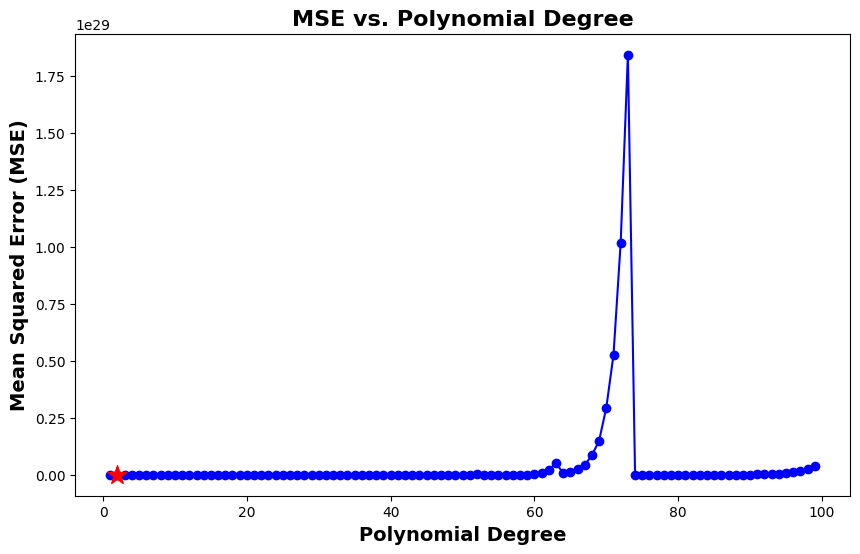

Lowest MSE: 31.8912 at Polynomial Degree: 2


In [54]:
mse = []
lowest_mse = float('inf')
degrees = range(1, 100)  # Testing polynomial degrees from 1 to 100
for degree in degrees:
    # Create the pipeline for the current degree
    poly_model = Pipeline([
        ("poly_features", PolynomialFeatures(degree=degree)),
        ("linear_regression", LinearRegression())
    ])
    
    # Fit the model and predict
    poly_model.fit(X_train, y_train)
    y_pred = poly_model.predict(X_test)
    
    # Calculate MSE and store it
    mse_value = mean_squared_error(y_test, y_pred)
    mse.append(mse_value)
    
    # Update lowest MSE if current MSE is lower
    if mse_value < lowest_mse:
        lowest_mse = mse_value
        lowest_mse_degree = degree

# Plotting MSE vs. Polynomial Degree
plt.figure(figsize=(10, 6))
plt.plot(degrees, mse, marker='o', linestyle='-', color='blue')
plt.scatter(lowest_mse_degree, lowest_mse, color='red', marker='*', s=200, label='Lowest MSE', zorder=3)
plt.xlabel('Polynomial Degree', fontsize=14, fontweight='bold')
plt.ylabel('Mean Squared Error (MSE)', fontsize=14, fontweight='bold')
plt.title('MSE vs. Polynomial Degree', fontsize=16, fontweight='bold')
plt.show()

print(f'Lowest MSE: {lowest_mse:.4f} at Polynomial Degree: {lowest_mse_degree}')

In [24]:
print(f"Lowest MSE: {lowest_mse:.4f} at Degree: {lowest_mse_degree}")

Lowest MSE: 4.8203 at Degree: 19
